In [1]:
import numpy as np
from copy import deepcopy

# for plotting if needed
import matplotlib
import matplotlib.pyplot as plt

In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent.parent.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT)) 

from muonscripts.constants import constants
from muonscripts.io_tools.read import read_cif
from muonscripts.io_tools.read import read_from_file

from muonscripts.undi_tools.second_moments import zero_field_distribution_powder

from muonscripts.undi_tools.atoms_scaling import scale_neighbors, partition_into_shells
from muonscripts.undi_tools.atoms_scaling import only_muon_cluster, compute_zeta_cluster

from muonscripts.undi_tools.atoms import build_undi_neighbors, build_undi_neighbors_from_file
from muonscripts.undi_tools.atoms import complete_undi_neighbors, neighbors_hilbert_dimension

from muonscripts.efg.point_charge import compute_efg
from muonscripts.efg.point_charge import sphere_radius_convergence
from muonscripts.efg.point_charge import build_point_charge_efg_neighbors

from muonscripts.efg.lattice_utils import get_atom_kinds 

# from muonscripts.efg.utils import nu_Q, quadrupole_frequencies, get_omegaQ_mu
# from muonscripts.efg.point_charge import compute_efg, point_charge_EFG, diagonalize_EFG, atom_dict_EFG

from muonscripts.muon_tools.displacements import radial_to_dict
from muonscripts.muon_tools.displacements import max_displacement
from muonscripts.muon_tools.displacements import select_radial_displacement

In [3]:
def load_raw_data_only(filename, x_min=0):
    """Reads the first 2-3 columns (xData, Data, [errData]) of a muSR
    data file, ignoring any other (e.g. theory) columns."""
    import pandas as pd
    
    df = pd.read_csv(filename, skipinitialspace=True)
    df = df.replace(r"^\s*$", np.nan, regex=True)
    cols = list(df.columns[:3])
    d = df[cols].dropna()
    xData = d[cols[0]].to_numpy(dtype=float)
    yData = d[cols[1]].to_numpy(dtype=float)
    errData = d[cols[2]].to_numpy(dtype=float) if len(cols) > 2 else None
    if x_min is not None:
        keep = xData >= x_min
        xData, yData = xData[keep], yData[keep]
        if errData is not None:
            errData = errData[keep]
    return xData, yData, errData


def _ordered_legend(ax, order_list, **legend_kwargs):
    handles, labels = ax.get_legend_handles_labels()

    def priority(label):
        for i, key in enumerate(order_list):
            if key in label:
                return i
        return len(order_list)

    entries = sorted(
        zip(handles, labels),
        key=lambda e: priority(e[1])
    )

    handles, labels = zip(*entries)

    return ax.legend(handles, labels, **legend_kwargs)

In [4]:
def powder_celio_signal(
    neighbors, 
    tlist, 
    k=2, 
    nrep=1,
    single_precision=False, 
    algorithm='light',
    log_level='',
    undi_path='/home/misah/projects/myproject/undi'
):
    """Powder-averaged P_z^mu(t) via undi.py's celio_on_steroids(), using
    the SAME exact 3-orthogonal-axis trick as the exact-diagonalization
    path elsewhere in this thread (mathematically exact for zero-field
    muon depolarization, independent of which method solves the
    dynamics underneath -- see wilkinson_prl_example.py's derivation).

    REQUIRES the compiled backend (fast_quantum_light or similar) that
    ships with the full `undi` package -- NOT importable from just
    undi.py + isotopes.py as used elsewhere in this thread. If you see
    ImportError here, you need `pip install undi` (or build the C++
    extensions from the undi source repo) rather than just using the
    loose undi.py file.

    nrep : int
        Number of independent Celio stochastic repeats to average over
        (in ADDITION to averaging over the 3 powder directions) -- more
        repeats reduce the Monte Carlo noise in the result. The paper's
        own SM mentions similar repeat-averaging for their Celio-based
        A15 simulations.
    """
    # Importing stuff...
    try:
        from undi import MuonNuclearInteraction
    except (ImportError, ModuleNotFoundError):
        import sys
        sys.path.append(undi_path)
        from undi import MuonNuclearInteraction

    signal = np.zeros(len(tlist))
    for direction in ([1, 0, 0], [0, 1, 0], [0, 0, 1]): # simple powder average
        NS = MuonNuclearInteraction(neighbors, log_level=log_level)
        NS.translate_rotate_sample_vec(direction)   # rotates geometry directly
        for _ in range(nrep):
            signal += NS.celio_on_steroids(
                tlist, k=k, single_precision=single_precision, progress=False, algorithm=algorithm
            )
    return signal / (3 * nrep)

In [5]:
def kubo_toyabe(tlist, Gmu_S2):
    """Calculates the Kubo-Toyabe polarization for the nuclear arrangement
        provided in input.

    Parameters
    ----------
    tlist : numpy.array
        List of times at which the muon polarization is observed.
    Gmu_S2 : float
        The product of gamma_mu and sigma^2.

    Returns
    -------
    numpy.array
        Kubo-Toyabe function, for a powder in zero field.
    """
    return 0.333333333333 + 0.6666666666 * \
            (1- Gmu_S2  *  np.power(tlist,2)) * \
            np.exp( - 0.5 * Gmu_S2 * np.power(tlist,2))

In [6]:
import os
dpath='./'

In [7]:
filename = os.path.join(dpath, 'CaF2.cif')
atoms = read_cif(filename) # or with read_from_file
# atoms = read_from_file(filename) # you can parse **read_kwargs depending on the type of the I/O

muon_position = [0.25, 0.25, 0.5] # assumed (not really!) muon positions

/home/misah/.virtualenvs/pyqm/lib/python3.10/site-packages/ase/io/cif.py:411: UserWarning: crystal system 'cubic' is not interpreted for space group Spacegroup(225, setting=1). This may result in wrong setting!
  warnings.warn(


In [8]:
file = "CaF2.cif"
file = os.path.join(dpath, file)

muon_position = np.array([0.25, 0.25, 0.50]) 
Q_overrides = None
CaF2_charges = {'Ca': +2, 'F': -1}
########################################################

ALL_CLUSTERS = {}
S2_VALUES = {}

UNPERTURBED_NEIGHBORS = {
    'ALL_CLUSTERS': {},
    'S2_VALUES': {},
    'SIGNALS': {}
}

cutoffs_settings = {
    ## "name" : [cutoffs, max_cutoff]
    'NN':  [{'F': 2.00}, 10],
    'NNN': [{'F': 4.00}, 10],
    'INF': [{'F': 40.0}, 40],
}

for name, (cutoffs, inf_cutoff) in cutoffs_settings.items():
    # print(name, cutoffs, inf_cutoff)
    print(f"== Building neighbor cluster for: {name} ==")
    neighbors = build_undi_neighbors_from_file(
        file,
        muon_position,
        cutoffs=cutoffs,
        inf_cutoff=inf_cutoff,
        efg_tensors=None,
        efg_factor=1.0,
        gamma_overrides=None,
        isotope_overrides=None,
        quadrupole_moments_overrides=Q_overrides,
        verbose_neighbors=False,
        # format='elk'
        # **read_kwargs,
    )

    # complete missing nuclear properties
    neighbors = complete_undi_neighbors(neighbors, log_level="")

    ALL_CLUSTERS[name] = deepcopy(neighbors)

    dim = neighbors_hilbert_dimension(neighbors)
    if dim < 1e6:
        print(f"---- The Hilbert space dimension is: {dim} x {dim} ----")
    else:
        import math
        # print(f"---- The Hilbert space dimension is: {dim:.3e} x {dim:.3e} ----")
        print(f"---- The Hilbert space dimension is ≈: 10^{math.log10(dim):.2f} x 10^{math.log10(dim):.2f} ----")

    # # calculate second moments
    if name != "NNN":
        S2_VALUES[name] = zero_field_distribution_powder(neighbors)

MU_ATOMS = only_muon_cluster(ALL_CLUSTERS["NN"])
ALL_CLUSTERS['MU'] = deepcopy(MU_ATOMS)

# Bare NN (i.e no muon)
shells = partition_into_shells(
    MU_ATOMS[0],
    [MU_ATOMS, ALL_CLUSTERS["NN"]],
    rtol=1e-4,
)
ALL_CLUSTERS['NN_BARE'] = deepcopy(shells[1])

# Bare NNN (i.e no muon and no NN atoms, only NNN)
shells = partition_into_shells(
    MU_ATOMS[0],
    [ALL_CLUSTERS["NN"], ALL_CLUSTERS["NNN"]],
    rtol=1e-4,
)
ALL_CLUSTERS['NNN_BARE'] = deepcopy(shells[1])

# calculate second moments (MUON + BARE NNN atoms)
S2_VALUES["NNN"] = zero_field_distribution_powder(
    MU_ATOMS + shells[1]
)

ZETA = (S2_VALUES["NNN"] / (S2_VALUES["INF"] - S2_VALUES["NN"])) ** (1 / 6)
# or with
ZETA = compute_zeta_cluster(ALL_CLUSTERS['INF'], [ALL_CLUSTERS['NN'], ALL_CLUSTERS['NNN']], rtol=1e-4)

print(f'---- calculated  ZETA (ζ)  parameter ζ = {ZETA:.4f} (paper: 0.943) ----')

UNPERTURBED_NEIGHBORS['ZETA'] = ZETA
UNPERTURBED_NEIGHBORS['S2_VALUES'] = S2_VALUES
UNPERTURBED_NEIGHBORS['ALL_CLUSTERS'] = ALL_CLUSTERS

== Building neighbor cluster for: NN ==
---- The Hilbert space dimension is: 8 x 8 ----
== Building neighbor cluster for: NNN ==
---- The Hilbert space dimension is: 2048 x 2048 ----
== Building neighbor cluster for: INF ==
---- The Hilbert space dimension is ≈: 10^3999.79 x 10^3999.79 ----
---- calculated  ZETA (ζ)  parameter ζ = 0.9433 (paper: 0.943) ----


In [9]:
gamma_sternheimer = {  # or gamma_inf, anti-shielding factors, for the ions in your material
    'Na': 4.0,
    # 'Mn': ...,  # add your own value here if you have one
}

# Formal ionic charges [units of e], only needed if compute_lattice_efg=True.
formal_charges = {
    'Na': +1, 'F': -1, 'Ca': +2, 'Li': +1, 'Cl': -1, 'Mg': +2, 'O': -2,
    'Al': +3,
    # add whatever your material contains
}

In [10]:
# Identify atom kinds

atm_kinds = get_atom_kinds(atoms)

print("\nAtom kinds:")
for kind, indices in atm_kinds.items():
    print(f"{kind}: {indices}")


print("\nCa indices:")
print(atm_kinds["Ca"])


Atom kinds:
Ca: [0, 1, 2, 3]
F: [4, 5, 6, 7, 8, 9, 10, 11]

Ca indices:
[0, 1, 2, 3]


In [11]:
# F_idx  = [i for i, s in enumerate(atoms.get_chemical_symbols()) if s == 'F']
# Ca_idx = [i for i, s in enumerate(atoms.get_chemical_symbols()) if s == 'Ca']

# test non zero spin Ca isotopes (e.g., 43Ca, I=7/2, Q=-0.0408e-28 m^2, 0.135% abundance)
Ca_nuclear_spin   = 7/2
Ca_Quadrupole_moment = -0.0408e-28  # m^2 (0.135 abundance)

CaF2_charges = {'Ca': +2, 'F': -1}
sphere_radius=60

In [12]:
probe_idx = atm_kinds["Ca"][0]
probe_pos = atoms.get_scaled_positions()[probe_idx]  

res = compute_efg(
    atoms, 
    probe_position=probe_pos, 
    atomic_charges=CaF2_charges, 
    sphere_radius=sphere_radius,
    gamma_sternheimer=-0.0, 
    exclude_indices=(), 
    extra_charges=None,
    coords_are_cartesian=False,
    nuclear_spin=Ca_nuclear_spin,
    quadrupole_moment=Ca_Quadrupole_moment,
    verbose=True
)

---- point charge EFG: lattice sum for 66950 charges within sphere radius 60.000 Å ----

EFG analysis for probe site at frac coord. (0.5000, 0.5000, 0.5000)
Vzz          =  1.46293534e+07 V/m^2
Vyy          =  1.22541945e+07 V/m^2
Vxx          =  9.66403746e+06 V/m^2
eta          =  0.17705205 (unitless)
chi_Q_MHz    =  0.00000000 MHz
nu_z_MHz     = -0.00000000 MHz
nu_Q_MHz     =  0.00000000 MHz

EFG tensor V_ab (V/m^2) =
----------------------------------------------------------------------
 [  1.22739546e+07,  1.53537640e+05,  9.09682661e+04 ]
 [  2.20307602e+05,  1.46053202e+07,  1.29792117e+05 ]
 [  5.95513543e+04,  1.24802497e+05,  9.66831057e+06 ]
----------------------------------------------------------------------
Trace(V_ab) =  3.65476e+07
Symmetric   = False

principal axes (unitless) = 
----------------------------------------------------------------------
 [ -2.07528696e-02, -9.95379416e-01, -9.37503953e-02 ]
 [ -2.43189253e-02,  9.42454176e-02, -9.95251923e-01 ]
 [  9.994

In [13]:
# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(figsize=(7, 4.5))

# radius_max = 200
# radius_step = 20
# radius_list = np.arange(10, radius_max, radius_step)

# results = sphere_radius_convergence(
#         atoms, 
#         site_position=atoms.get_positions()[idx], 
#         charges=CaF2_charges, 
#         exclude_indices=(), 
#         extra_charges=None, 
#         quadrupole_moment=Ca_Quadrupole_moment,
#         gamma_sternheimer=0.0,
#         conv_thr=1e-2, 
#         sphere_radius_list=radius_list, 
#         sphere_radius_step=radius_step, 
#         sphere_radius_max=radius_max,
#         num_conv_streak=3, 
#         ax=ax
# )

In [14]:
# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(figsize=(7, 4.5))

# radius_list, Vzz_values, rel_error = results[0], results[1], results[2]


# mask = rel_error > 0 # log scale can't show the exact-zero final point
# ax.semilogy(np.array(radius_list)[mask], rel_error[mask], 'o-')
# ax.set_xlabel('sphere radius (Angstrom)')
# ax.set_ylabel('relative error vs. largest-radius estimate')
# ax.set_title('EFG (Vzz): real-space sum convergence')
# ax.grid(True, which='both', alpha=0.3)

In [15]:
file = 'relax.in'
file = os.path.join(dpath, file)
inp_ase  = read_from_file(file, format="espresso-in")
inp_ase2 = inp_ase.copy() 

In [16]:
file = 'relax.out'
file = os.path.join(dpath, file)
rlx_ase  = read_from_file(file, format="espresso-out", index=-1)
rlx_ase2 = rlx_ase.copy()

In [17]:
# get and remove muon position
rlx_ase2 =  rlx_ase.copy()
if 1 not in rlx_ase2.numbers:
    raise ValueError("No Hydrogen (atomic number 1) found in rlx_ase2.")
mu_idx = np.where(rlx_ase2.numbers == 1)[0][-1]
mupos_rlx = rlx_ase2.get_scaled_positions()[mu_idx]
del rlx_ase2[mu_idx]

mupos_rlx

array([0.12500015, 0.12500015, 0.25001247])

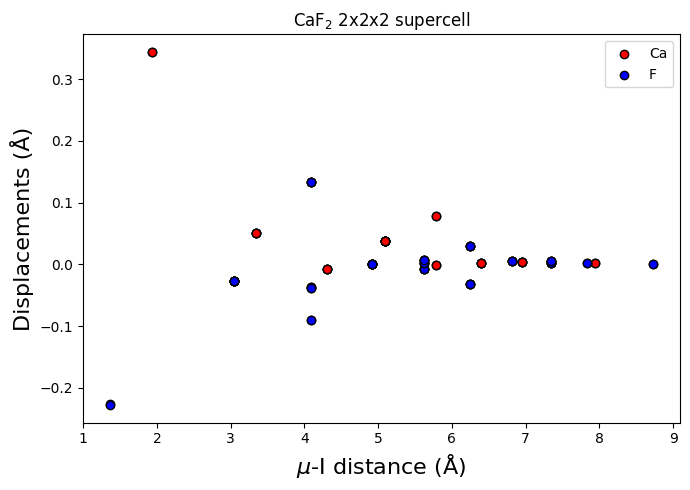

In [18]:
radial_res = radial_to_dict(inp_ase.copy(), rlx_ase.copy(), muon_label='H')


fontsize=16
fig, ax = plt.subplots(figsize=(7, 5))

sel = select_radial_displacement(
    radial_res,
    species='Ca',
    distance_type='unperturbed',
    # cutoff=6.0,          # None -> no cutoff, keep everything
)
ax.scatter(sel['distance'], sel['displacements'], color='red', edgecolor='k', label='Ca')

sel = select_radial_displacement(
    radial_res,
    species='F',
    distance_type='unperturbed',
    # cutoff=6.0,          # None -> no cutoff, keep everything
)
ax.scatter(sel['distance'], sel['displacements'], color='blue', edgecolor='k', label='F')

ax.set_title(r'CaF$_2$ 2x2x2 supercell')
ax.set_xlabel(r'$\mu$-I distance (Å)', fontsize=fontsize)
ax.set_ylabel(r'Displacements (Å)' , fontsize=fontsize)

ax.legend()
plt.tight_layout()
plt.show()

In [19]:
max_displacement(inp_ase.copy(), rlx_ase.copy())

np.float64(0.34381714730782353)

In [20]:
F_rlx_idx  = [i for i, s in enumerate(rlx_ase2.get_chemical_symbols()) if s == 'F']
Ca_rlx_idx = [i for i, s in enumerate(rlx_ase2.get_chemical_symbols()) if s == 'Ca']

In [21]:
probe_idx = Ca_rlx_idx[0]
probe_pos = rlx_ase2.get_scaled_positions()[probe_idx]  

res = compute_efg(
    rlx_ase2, 
    probe_position=probe_pos, 
    atomic_charges=CaF2_charges, 
    sphere_radius=sphere_radius,
    gamma_sternheimer=-0.0, 
    exclude_indices=(), 
    extra_charges=None,
    coords_are_cartesian=False,
    nuclear_spin=Ca_nuclear_spin,
    quadrupole_moment=Ca_Quadrupole_moment,
    verbose=True
)

---- point charge EFG: lattice sum for 67010 charges within sphere radius 60.000 Å ----

EFG analysis for probe site at frac coord. (0.2723, 0.2723, 0.2500)
Vzz          = -5.27908769e+19 V/m^2
Vyy          =  4.15158878e+19 V/m^2
Vxx          =  1.12749891e+19 V/m^2
eta          =  0.57284327 (unitless)
chi_Q_MHz    =  0.05208029 MHz
nu_z_MHz     =  0.00372002 MHz
nu_Q_MHz     =  0.00391820 MHz

EFG tensor V_ab (V/m^2) =
----------------------------------------------------------------------
 [ -5.63748964e+18, -4.71533774e+19, -1.77016115e+16 ]
 [ -4.71533774e+19, -5.63748964e+18, -1.77016115e+16 ]
 [ -1.77016115e+16, -1.77016115e+16,  1.12749793e+19 ]
----------------------------------------------------------------------
Trace(V_ab) =  2.74227e+06
Symmetric   = True

principal axes (unitless) = 
----------------------------------------------------------------------
 [  2.76303342e-04,  7.07106781e-01,  7.07106727e-01 ]
 [  2.76303342e-04, -7.07106781e-01,  7.07106727e-01 ]
 [ -9.9999